In [1]:
# ============================================================
# Notebook 05 — Prophet Modelling
# Baseline V1: Default settings, yearly seasonality
# Reference: Taylor & Letham (2018)
# Implementation: Meta Prophet library
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings('ignore')

PROCESSED = Path('../data/processed')
FIGURES = Path('../outputs/figures')

# Load all four series
ndvi_amazon_train = pd.read_csv(PROCESSED / 'ndvi_amazon_train.csv', parse_dates=['date'])
ndvi_amazon_test = pd.read_csv(PROCESSED / 'ndvi_amazon_test.csv', parse_dates=['date'])

ndvi_sahel_train = pd.read_csv(PROCESSED / 'ndvi_sahel_train.csv', parse_dates=['date'])
ndvi_sahel_test = pd.read_csv(PROCESSED / 'ndvi_sahel_test.csv', parse_dates=['date'])

sst_atlantic_train = pd.read_csv(PROCESSED / 'sst_atlantic_train.csv', parse_dates=['date'])
sst_atlantic_test = pd.read_csv(PROCESSED / 'sst_atlantic_test.csv', parse_dates=['date'])

sst_indian_train = pd.read_csv(PROCESSED / 'sst_indian_train.csv', parse_dates=['date'])
sst_indian_test = pd.read_csv(PROCESSED / 'sst_indian_test.csv', parse_dates=['date'])

print("All series loaded successfully")

Importing plotly failed. Interactive plots will not work.


All series loaded successfully


22:47:58 - cmdstanpy - INFO - Chain [1] start processing
22:47:59 - cmdstanpy - INFO - Chain [1] done processing


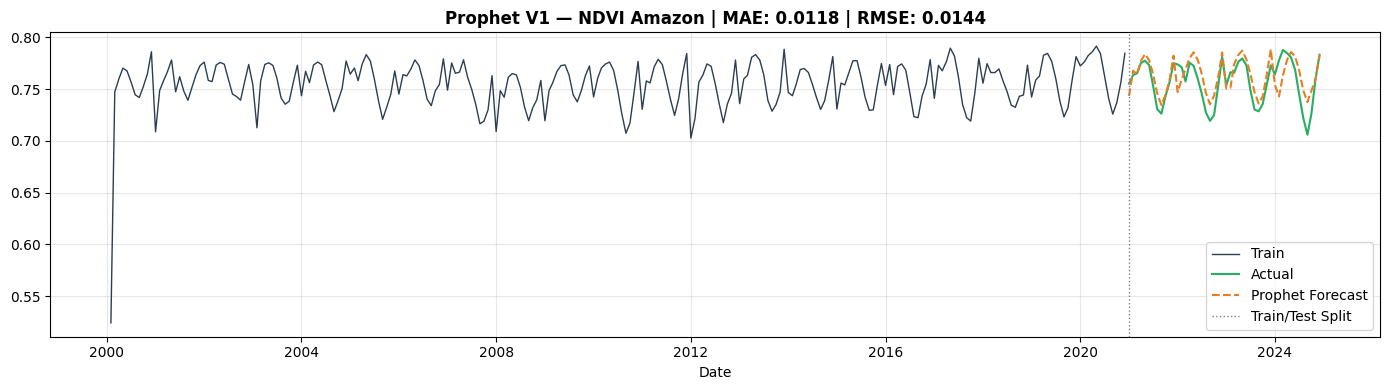

22:48:00 - cmdstanpy - INFO - Chain [1] start processing
22:48:00 - cmdstanpy - INFO - Chain [1] done processing


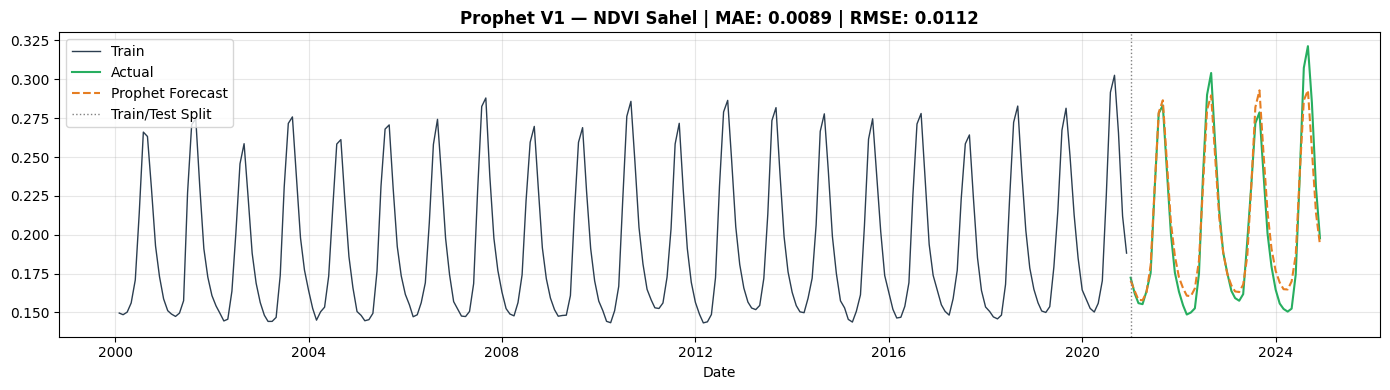

22:48:00 - cmdstanpy - INFO - Chain [1] start processing
22:48:00 - cmdstanpy - INFO - Chain [1] done processing


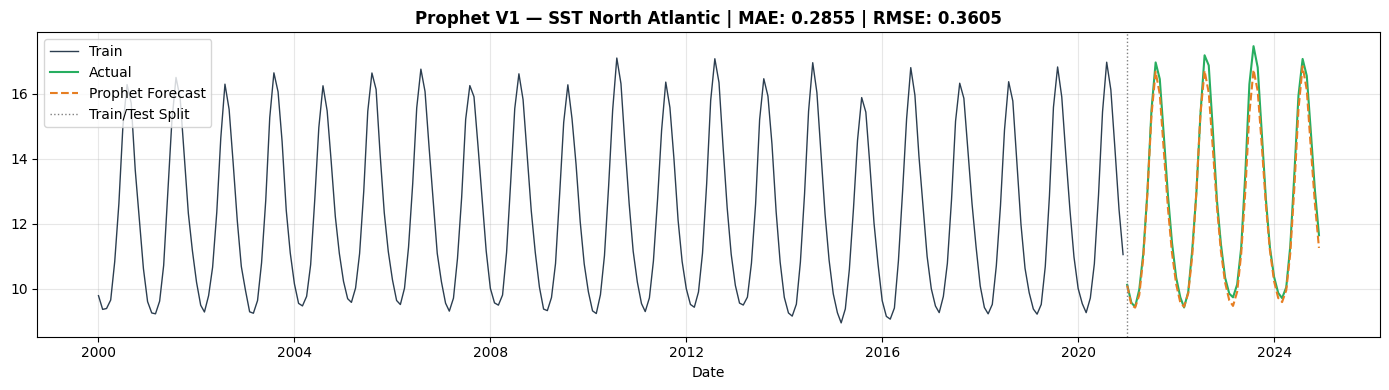

22:48:01 - cmdstanpy - INFO - Chain [1] start processing
22:48:01 - cmdstanpy - INFO - Chain [1] done processing


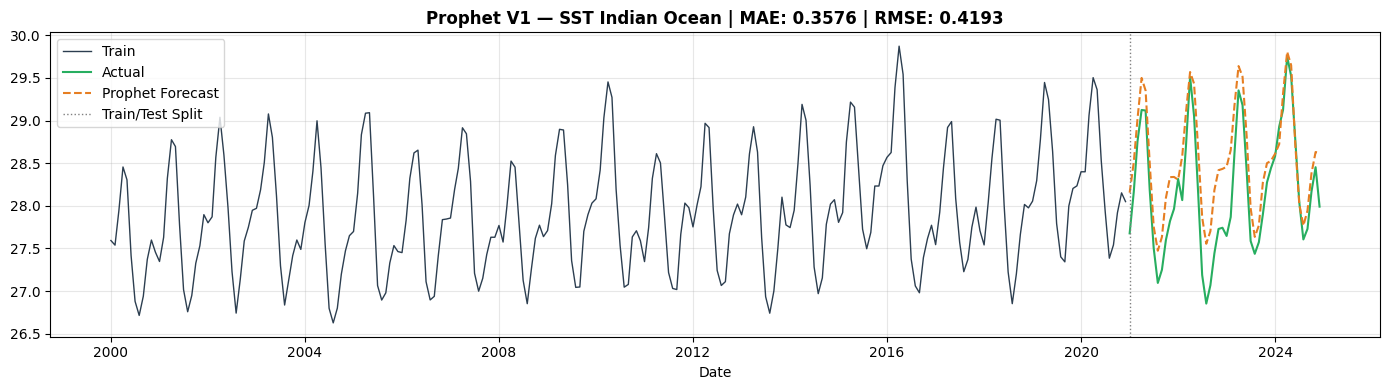


=== Prophet V1 Baseline Results ===
            series    MAE   RMSE
       NDVI Amazon 0.0118 0.0144
        NDVI Sahel 0.0089 0.0112
SST North Atlantic 0.2855 0.3605
  SST Indian Ocean 0.3576 0.4193


In [2]:
# ============================================================
# Prophet V1 — Baseline, default settings, yearly seasonality
# Prophet requires columns named 'ds' (date) and 'y' (value)
# Additive mode, yearly seasonality enabled
# ============================================================

def run_prophet(train, test, value_col, series_name):
    # Prophet requires ds/y format
    train_prophet = train[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    test_prophet = test[['date', value_col]].rename(
        columns={'date': 'ds', value_col: 'y'})
    
    # Fit model
    model = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    model.fit(train_prophet)
    
    # Forecast
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)
    forecast_test = forecast.tail(len(test))['yhat'].values
    actual = test[value_col].values
    
    # Metrics
    mae = mean_absolute_error(actual, forecast_test)
    rmse = np.sqrt(mean_squared_error(actual, forecast_test))
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train['date'], train[value_col],
            color='#2c3e50', linewidth=1, label='Train')
    ax.plot(test['date'], actual,
            color='#27ae60', linewidth=1.5, label='Actual')
    ax.plot(test['date'], forecast_test,
            color='#e67e22', linewidth=1.5, linestyle='--', label='Prophet Forecast')
    ax.axvline(x=test['date'].iloc[0], color='grey',
               linestyle=':', linewidth=1, label='Train/Test Split')
    ax.set_title(f'Prophet V1 — {series_name} | MAE: {mae:.4f} | RMSE: {rmse:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"fig_prophet_v1_{series_name.lower().replace(' ', '_')}.png"
    plt.savefig(FIGURES / filename, dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'series': series_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Run V1 on all four series
results = []

results.append(run_prophet(ndvi_amazon_train, ndvi_amazon_test,
                            'ndvi_mean', 'NDVI Amazon'))

results.append(run_prophet(ndvi_sahel_train, ndvi_sahel_test,
                            'ndvi_mean', 'NDVI Sahel'))

results.append(run_prophet(sst_atlantic_train, sst_atlantic_test,
                            'sst_mean', 'SST North Atlantic'))

results.append(run_prophet(sst_indian_train, sst_indian_test,
                            'sst_mean', 'SST Indian Ocean'))

# Results table
results_df = pd.DataFrame(results)
print("\n=== Prophet V1 Baseline Results ===")
print(results_df.to_string(index=False))